In [1]:
import argparse
import sys

import numpy as np

sys.path.insert(0, ".")
sys.path.insert(1, "..")
sys.path.append("../")
import pandas as pd
from __future__ import annotations

import json
import os
from collections import defaultdict
from typing import Dict, Iterable, List, Optional, Tuple

import selfies as sf
from rdkit import Chem, RDLogger
from rdkit.Chem.Scaffolds import MurckoScaffold

RDLogger.DisableLog("rdApp.*")

ALLOWED_ELEMENTS = {"C", "N", "O", "S", "F", "Cl", "Br", "I", "P", "B"}

In [1]:
%%atlas_sql
SHOW DATABASES

,name
0,INFORMATION_SCHEMA
1,atlas_analytics
2,atlas_dictionaries
3,default
4,information_schema
5,system


,name
0,INFORMATION_SCHEMA
1,atlas_analytics
2,atlas_dictionaries
3,default
4,information_schema
5,system


In [ ]:
# Warehouse query (ClickHouse via atlas-compute)
wh = computeclient.create_client("warehouse")
df = wh.execute("""SELECT * FROM system.tables LIMIT 100""")
df

In [ ]:
# Text search (OpenSearch via atlas-compute)
import pandas as pd
search = computeclient.create_client("search_and_analytics")
res = search.search(index="index_name", q="query", size=20)
df_1 = pd.json_normalize([h["_source"] for h in res["hits"]["hits"]])
df_1

In [ ]:
# Quick chart — edit x / y to your columns
import matplotlib.pyplot as plt
ax = df.plot()  # e.g. df.plot(x="date", y="value", kind="line")
plt.tight_layout(); plt.show()

In [2]:
allowed = ALLOWED_ELEMENTS

In [3]:
smiles = "CCOc1ccc(OCC)c([C@H]2C(C#N)=C(N)N(c3ccccc3C(F)(F)F)C3=C2C(=O)CCC3)c1"
mol = Chem.MolFromSmiles(smiles)

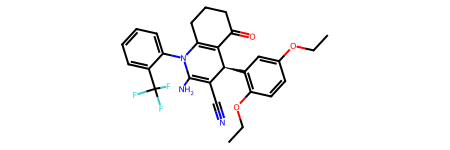

In [4]:
mol

In [5]:
frags = Chem.GetMolFrags(mol, asMols=True, sanitizeFrags=False)
frags

(<rdkit.Chem.rdchem.Mol at 0x1a151d21690>,)

In [6]:
mol = max(frags, key=lambda m: m.GetNumHeavyAtoms())

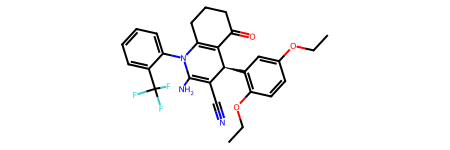

In [7]:
mol

In [8]:
Chem.SanitizeMol(mol)

rdkit.Chem.rdmolops.SanitizeFlags.SANITIZE_NONE

In [9]:
max_heavy=60
if mol.GetNumHeavyAtoms() > max_heavy or mol.GetNumHeavyAtoms() < 4:
    print("NUmber of heavy atoms is greater than the number of maximum heavy atoms")

In [10]:
mol.GetNumHeavyAtoms()

36

In [11]:
for atom in mol.GetAtoms():
    if atom.GetSymbol() not in allowed:
        print(f"{atom.GetSymbol()} is not allowed")

In [12]:
if any(a.GetFormalCharge() != 0 for a in mol.GetAtoms()):
    print(f"Formal charge is greater than 0")

In [13]:
[a.GetFormalCharge() for a in mol.GetAtoms() ]

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0]

In [14]:
Chem.MolToSmiles(mol, canonical=True)

'CCOc1ccc(OCC)c([C@H]2C(C#N)=C(N)N(c3ccccc3C(F)(F)F)C3=C2C(=O)CCC3)c1'

In [15]:
s = sf.encoder(smiles)

In [16]:
s

'[C][C][O][C][=C][C][=C][Branch1][Ring2][O][C][C][C][Branch2][Ring2][N][C@H1][C][Branch1][Ring1][C][#N][=C][Branch1][C][N][N][Branch1][P][C][=C][C][=C][C][=C][Ring1][=Branch1][C][Branch1][C][F][Branch1][C][F][F][C][=C][Ring2][Ring1][Ring1][C][=Branch1][C][=O][C][C][C][Ring1][#Branch1][=C][Ring2][Ring1][P]'

In [17]:
back = sf.decoder(s)

In [18]:
back

'CCOC1=CC=C(OCC)C([C@H1]2C(C#N)=C(N)N(C3=CC=CC=C3C(F)(F)F)C4=C2C(=O)CCC4)=C1'

In [19]:
smiles

'CCOc1ccc(OCC)c([C@H]2C(C#N)=C(N)N(c3ccccc3C(F)(F)F)C3=C2C(=O)CCC3)c1'

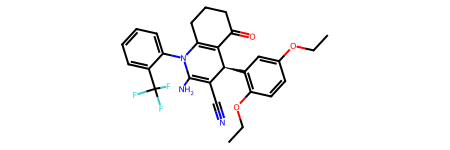

In [20]:
m = Chem.MolFromSmiles(back)
m

In [21]:
Chem.MolToSmiles(m, canonical=True) != smiles

False

In [22]:
MurckoScaffold.MurckoScaffoldSmiles(smiles=smiles, includeChirality=False)

'O=C1CCCC2=C1C(c1ccccc1)C=CN2c1ccccc1'

In [23]:
import selfies as sf


In [24]:
alphabet = sf.get_alphabet_from_selfies(["[C][C][O][C][=C][C][=C][Branch1][Ring2][O][C][C][C][Branch2][Ring2][N][C@H1][C][Branch1][Ring1][C][#N][=C][Branch1][C][N][N][Branch1][P][C][=C][C][=C][C][=C][Ring1][=Branch1][C][Branch1][C][F][Branch1][C][F][F][C][=C][Ring2][Ring1][Ring1][C][=Branch1][C][=O][C][C][C][Ring1][#Branch1][=C][Ring2][Ring1][P]"])

In [25]:
PAD = "[PAD]"
MASK = "[MASK]"
BOS = "[BOS]"

In [26]:

from __future__ import annotations

import json
from dataclasses import dataclass
from typing import Iterable, List, Optional, Sequence

import selfies as sf

PAD = "[PAD]"
MASK = "[MASK]"
BOS = "[BOS]"

@dataclass
class SelfiesTokenizer:
    symbols: List[str]
    n_prefix: int = 8
    max_len: int = 128

    # ---- construction ----------------------------------------------------
    @staticmethod
    def build(
        selfies_strings: Iterable[str],
        n_prefix: int = 8,
        max_len: int = 128
    ) -> "SelfiesTokenizer":
        """Build the alphabet from TRAINING data only. Using the full dataset
        here is a leakage bug that is invisible until someone asks."""
        alphabet = sf.get_alphabet_from_selfies(selfies_strings)
        return SelfiesTokenizer(sorted(alphabet), n_prefix=n_prefix, max_len=max_len)

    def save(self, path: str) -> None:
        with open(path, "w") as f:
            json.dump({"symbols": self.symbols,
                       "n_prefix": self.n_prefix,
                       "max_len": self.max_len}, f)

    @staticmethod
    def load(path: str) -> "SelfiesTokenizer":
        with open(path) as f:
            d = json.load(f)
        return SelfiesTokenizer(**d)

    # ---- vocabulary ------------------------------------------------------
    def __post_init__(self):
        self.prefix_tokens = [f"[P{i}]" for i in range(self.n_prefix)]
        self.itos: List[str] = [PAD, MASK, BOS] + self.prefix_tokens + list(self.symbols)
        self.stoi = {s: i for i, s in enumerate(self.itos)}

        self.pad_id = self.stoi[PAD]
        self.mask_id = self.stoi[MASK]
        self.bos_id = self.stoi[BOS]
        self.prefix_ids = [self.stoi[t] for t in self.prefix_tokens]

        # Positions 0..n_prefix are BOS + prefix: structural, never masked.
        self.n_struct = 1 + self.n_prefix

    @property
    def vocab_size(self) -> int:
        return len(self.itos)

    # ---- encode / decode -------------------------------------------------
    def encode(self, selfies_str: str) -> Optional[List[int]]:
        """SELFIES string -> padded id list. Returns None if it does not fit."""
        toks = list(sf.split_selfies(selfies_str))
        if len(toks) + self.n_struct > self.max_len:
            return None
        try:
            body = [self.stoi[t] for t in toks]
        except KeyError:
            return None                      # OOV symbol: not in training alphabet
        ids = [self.bos_id] + self.prefix_ids + body
        ids += [self.pad_id] * (self.max_len - len(ids))
        return ids

    def decode(self, ids: Sequence[int]) -> str:
        """id list -> SELFIES string.

        Decoding TRUNCATES at the first [PAD] after the structural prefix.
        [PAD] is the model's learned terminator (see data/dataset.make_masks),
        so anything after it is not part of the molecule. Skipping pads instead
        of truncating would splice disconnected fragments together and inflate
        apparent validity while producing chemistry the model did not intend.

        A [MASK] surviving to decode time indicates a sampler bug; we stop there
        rather than silently emitting a different molecule.
        """
        out = []
        for j, i in enumerate(ids):
            if j < self.n_struct:                 # BOS + prefix
                continue
            tok = self.itos[int(i)]
            if tok in (PAD, MASK):
                break                             # learned terminator
            if tok == BOS or tok in self.prefix_tokens:
                continue
            out.append(tok)
        return "".join(out)

    def decode_smiles(self, ids: Sequence[int]) -> Optional[str]:
        try:
            return sf.decoder(self.decode(ids))
        except Exception:
            return None

    # ---- masks -----------------------------------------------------------
    def structural_mask(self, ids) -> "list[bool]":
        """True where the position is BOS/prefix (never masked, never a target)."""
        return [j < self.n_struct for j in range(len(ids))]


In [27]:
out = SelfiesTokenizer(sorted(alphabet), n_prefix=8, max_len=128)

In [28]:
prefix_tokens = [f"[P{i}]" for i in range(8)]
itos: List[str] = [PAD, MASK, BOS] + prefix_tokens + list(out.symbols)
stoi = {s: i for i, s in enumerate(itos)}

pad_id = stoi[PAD]
mask_id = stoi[MASK]
bos_id = stoi[BOS]
prefix_ids = [stoi[t] for t in prefix_tokens]

# Positions 0..n_prefix are BOS + prefix: structural, never masked.
n_struct = 1 + 8

In [29]:
prefix_tokens

['[P0]', '[P1]', '[P2]', '[P3]', '[P4]', '[P5]', '[P6]', '[P7]']

In [30]:
itos

['[PAD]',
 '[MASK]',
 '[BOS]',
 '[P0]',
 '[P1]',
 '[P2]',
 '[P3]',
 '[P4]',
 '[P5]',
 '[P6]',
 '[P7]',
 '[#Branch1]',
 '[#N]',
 '[=Branch1]',
 '[=C]',
 '[=O]',
 '[Branch1]',
 '[Branch2]',
 '[C@H1]',
 '[C]',
 '[F]',
 '[N]',
 '[O]',
 '[P]',
 '[Ring1]',
 '[Ring2]']

In [31]:
stoi

{'[PAD]': 0,
 '[MASK]': 1,
 '[BOS]': 2,
 '[P0]': 3,
 '[P1]': 4,
 '[P2]': 5,
 '[P3]': 6,
 '[P4]': 7,
 '[P5]': 8,
 '[P6]': 9,
 '[P7]': 10,
 '[#Branch1]': 11,
 '[#N]': 12,
 '[=Branch1]': 13,
 '[=C]': 14,
 '[=O]': 15,
 '[Branch1]': 16,
 '[Branch2]': 17,
 '[C@H1]': 18,
 '[C]': 19,
 '[F]': 20,
 '[N]': 21,
 '[O]': 22,
 '[P]': 23,
 '[Ring1]': 24,
 '[Ring2]': 25}

In [32]:
n_struct

9